In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

In [3]:
df = pd.read_excel("Final_dataset.xlsx")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (259, 9)


,Bulk density (g/cm³),Porosity (%),Carbonization temperature (˚C),Heating rate (˚C/min),Holding time (hr),Compressive strength (Mpa),Precursor,Precursor_Category,Log_Compressive_Strength
0,0.32,84.1,1000,3.0,1.0,2.9,Kingwood coal,Other,1.064711
1,0.33,82.7,1000,3.0,1.0,5.5,Lower War Eagle coal,Other,1.704748
2,0.38,80.3,1000,3.0,1.0,8.0,Bakerstown coal-01,Other,2.079442
3,0.40,79.3,1000,3.0,1.0,9.9,Bakerstown coal-02,Other,2.292535
4,0.25,87.0,1000,3.0,1.0,2.5,Powellton extract-01,Other,0.916291


In [4]:
# Target
y = df["Log_Compressive_Strength"]

# Remove unwanted columns
X = df.drop(columns=[
    "Compressive strength (Mpa)",
    "Log_Compressive_Strength",
    "Precursor"
])

# One-hot encoding
X = pd.get_dummies(X, columns=["Precursor_Category"], drop_first=True)

print("Final Feature Shape:", X.shape)
print(X.dtypes)

Final Feature Shape: (259, 10)
Bulk density (g/cm³)                  float64
Porosity (%)                          float64
Carbonization temperature (˚C)          int64
Heating rate (˚C/min)                 float64
Holding time (hr)                     float64
Precursor_Category_Composite-based       bool
Precursor_Category_Other                 bool
Precursor_Category_Pitch-based           bool
Precursor_Category_Polymer-based         bool
Precursor_Category_Resin-based           bool
dtype: object


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (207, 10)
Test: (52, 10)


In [6]:
# Initialize
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=300, random_state=42)
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [7]:
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name}")
    print("R2:", round(r2,4))
    print("RMSE:", round(rmse,4))
    print("MAE:", round(mae,4))
    return r2

r2_lr = evaluate("Linear Regression", y_test, lr_pred)
r2_rf = evaluate("Random Forest", y_test, rf_pred)
r2_xgb = evaluate("XGBoost", y_test, xgb_pred)


Linear Regression
R2: 0.3691
RMSE: 1.7102
MAE: 1.2707

Random Forest
R2: 0.8056
RMSE: 0.9492
MAE: 0.6591

XGBoost
R2: 0.8
RMSE: 0.9628
MAE: 0.6903


In [8]:
total = r2_rf + r2_xgb
w_rf = r2_rf / total
w_xgb = r2_xgb / total

ensemble_pred = (w_rf * rf_pred) + (w_xgb * xgb_pred)

r2_ens = r2_score(y_test, ensemble_pred)
rmse_ens = np.sqrt(mean_squared_error(y_test, ensemble_pred))
mae_ens = mean_absolute_error(y_test, ensemble_pred)

print("\nEnsemble")
print("R2:", round(r2_ens,4))
print("RMSE:", round(rmse_ens,4))
print("MAE:", round(mae_ens,4))


Ensemble
R2: 0.811
RMSE: 0.9359
MAE: 0.6556


In [9]:
actual_mpa = 10 ** y_test
predicted_mpa = 10 ** ensemble_pred

rmse_mpa = np.sqrt(mean_squared_error(actual_mpa, predicted_mpa))
mae_mpa = mean_absolute_error(actual_mpa, predicted_mpa)

print("Real RMSE (MPa):", round(rmse_mpa,3))
print("Real MAE (MPa):", round(mae_mpa,3))

Real RMSE (MPa): 5348.769
Real MAE (MPa): 832.19


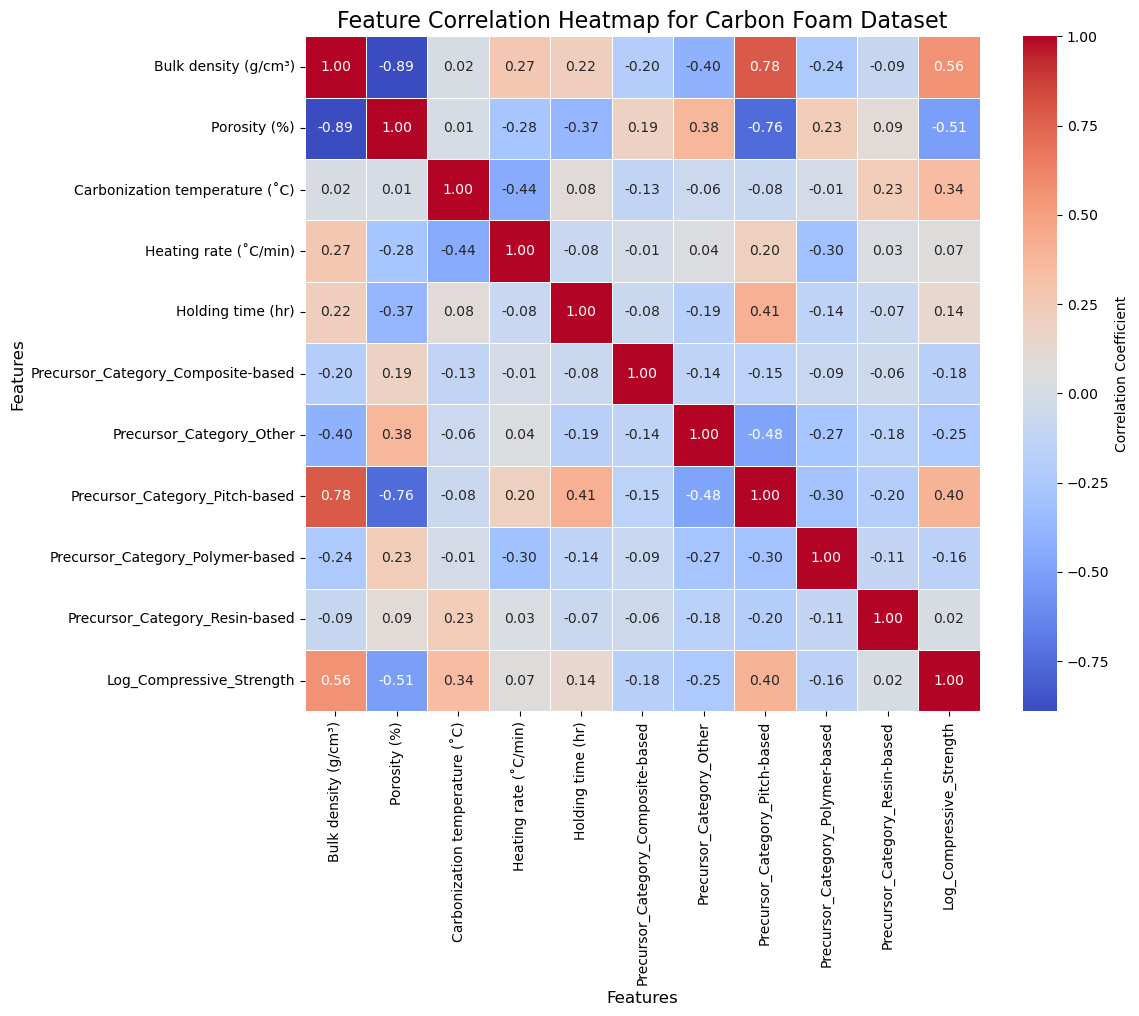

In [10]:
import os

temp_df = X.copy()
temp_df["Log_Compressive_Strength"] = y

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    temp_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Feature Correlation Heatmap for Carbon Foam Dataset", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()

# Save the graph
plt.savefig("graphs/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

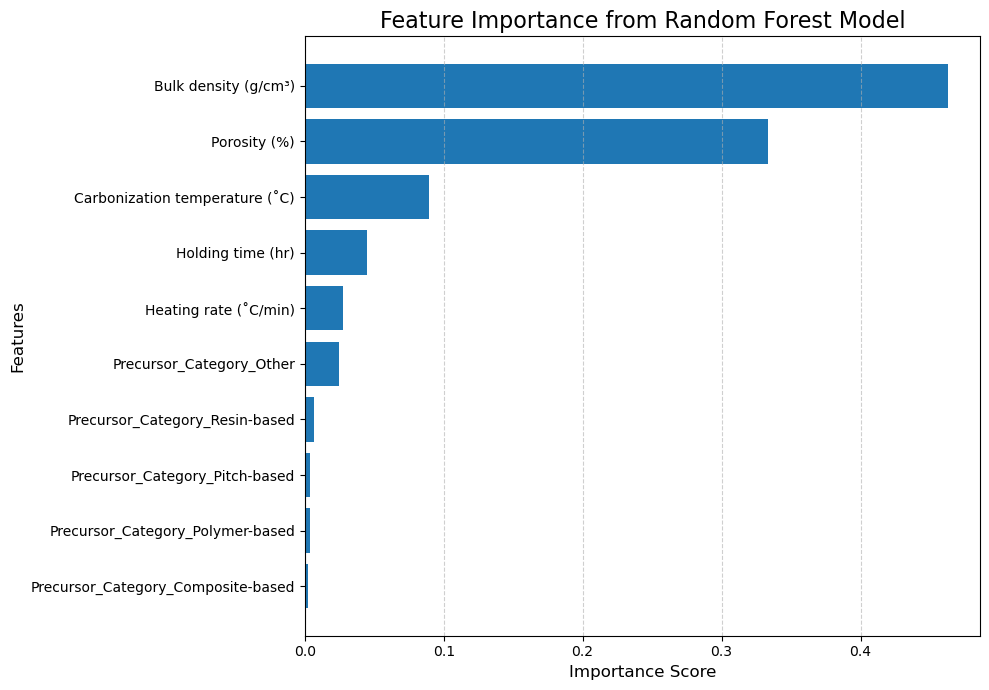

,Feature,Importance
0,Bulk density (g/cm³),0.462793
1,Porosity (%),0.333553
2,Carbonization temperature (˚C),0.089440
4,Holding time (hr),0.044968
3,Heating rate (˚C/min),0.027297
6,Precursor_Category_Other,0.024791
9,Precursor_Category_Resin-based,0.006581
7,Precursor_Category_Pitch-based,0.004087
8,Precursor_Category_Polymer-based,0.003879
5,Precursor_Category_Composite-based,0.002612


In [11]:
import os

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(10,7))

plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance from Random Forest Model", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/feature_importance_rf.png", dpi=300, bbox_inches="tight")

plt.show()

feature_importance

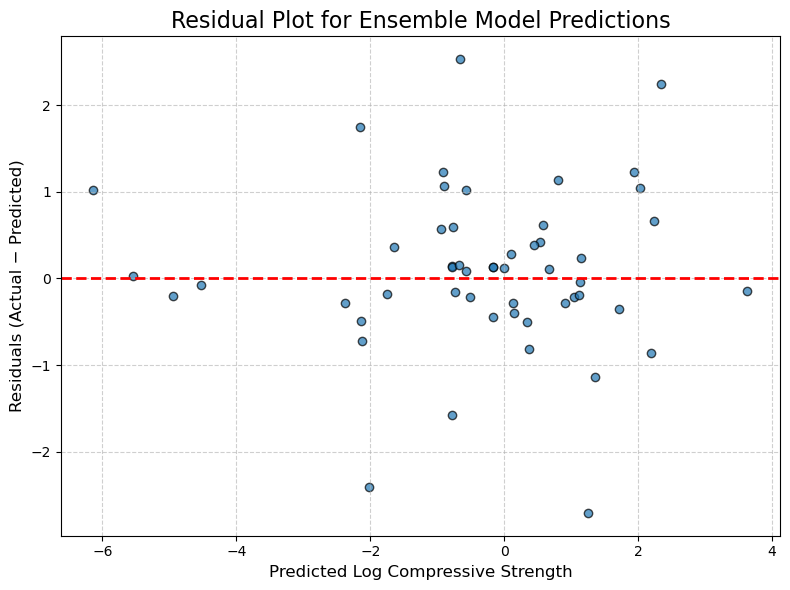

In [12]:
import os

residuals = y_test - ensemble_pred

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(8,6))

plt.scatter(
    ensemble_pred,
    residuals,
    edgecolors="black",
    alpha=0.7
)

plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Predicted Log Compressive Strength", fontsize=12)
plt.ylabel("Residuals (Actual − Predicted)", fontsize=12)

plt.title("Residual Plot for Ensemble Model Predictions", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/residual_plot_ensemble.png", dpi=300, bbox_inches="tight")

plt.show()

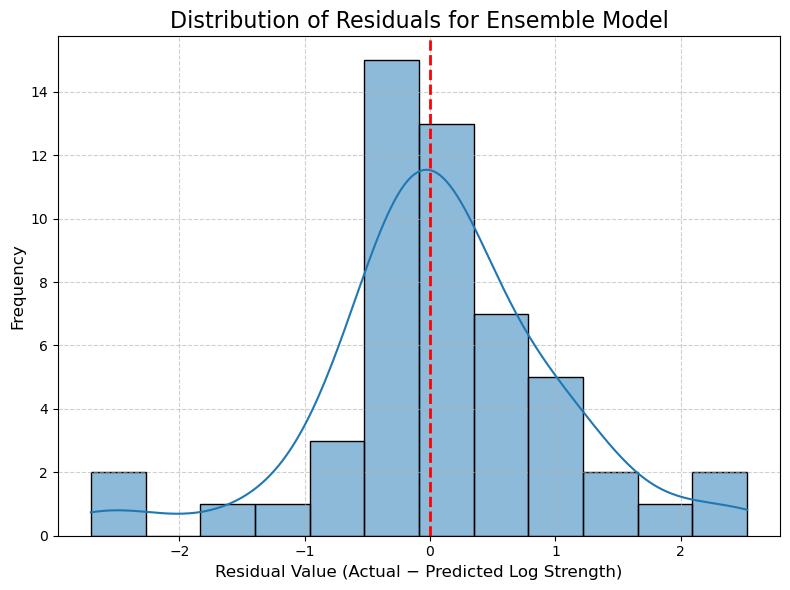

In [13]:
import os

# Create graphs folder if it does not exist
os.makedirs("graphs", exist_ok=True)

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Residual Value (Actual − Predicted Log Strength)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.title("Distribution of Residuals for Ensemble Model", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

# Save graph
plt.savefig("graphs/residual_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
def predict_strength(
    bulk_density,
    porosity,
    carbonization_temp,
    heating_rate,
    holding_time,
    precursor_category
):
    
    input_dict = {
        "Bulk density (g/cm³)": bulk_density,
        "Porosity (%)": porosity,
        "Carbonization temperature (˚C)": carbonization_temp,
        "Heating rate (˚C/min)": heating_rate,
        "Holding time (hr)": holding_time,
    }
    
    for col in X.columns:
        if "Precursor_Category_" in col:
            input_dict[col] = 0

    category_col = "Precursor_Category_" + precursor_category
    if category_col in input_dict:
        input_dict[category_col] = 1

    input_df = pd.DataFrame([input_dict])

    rf_val = rf.predict(input_df)[0]
    xgb_val = xgb.predict(input_df)[0]
    ensemble_val = (w_rf * rf_val) + (w_xgb * xgb_val)

    strength_mpa = 10 ** ensemble_val
    strength_mpa = round(float(strength_mpa), 3)

    print("\n======================================")
    print(" Carbon Foam Strength Prediction")
    print("======================================")
    print(f"Predicted Compressive Strength: {strength_mpa} MPa")
    print("======================================\n")

    return strength_mpa

In [15]:
predict_strength(
    bulk_density=0.45,
    porosity=80,
    carbonization_temp=900,
    heating_rate=5,
    holding_time=2,
    precursor_category="Pitch-based"
)


 Carbon Foam Strength Prediction
Predicted Compressive Strength: 2.003 MPa



2.003

In [16]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(xgb, "xgb_model.pkl")

print("Models saved.")

Models saved.


In [17]:
import tkinter as tk
from tkinter import ttk
import pandas as pd
import numpy as np

# ===============================
# Prediction Function
# ===============================

def predict_strength_gui():
    try:
        bulk_density = float(entry_bulk.get().strip())
        porosity = float(entry_poro.get().strip())
        carbon_temp = float(entry_temp.get().strip())
        heating_rate = float(entry_heat.get().strip())
        holding_time = float(entry_hold.get().strip())
        precursor = combo_precursor.get().strip()

        if precursor == "":
            result_var.set("Select precursor category")
            return

        # Prepare input dictionary
        input_dict = {
            "Bulk density (g/cm³)": bulk_density,
            "Porosity (%)": porosity,
            "Carbonization temperature (˚C)": carbon_temp,
            "Heating rate (˚C/min)": heating_rate,
            "Holding time (hr)": holding_time,
        }

        # Initialize all category columns to 0
        for col in X.columns:
            if "Precursor_Category_" in col:
                input_dict[col] = 0

        # Activate selected category
        category_col = "Precursor_Category_" + precursor
        if category_col in input_dict:
            input_dict[category_col] = 1

        input_df = pd.DataFrame([input_dict])

        # Predict
        rf_val = rf.predict(input_df)[0]
        xgb_val = xgb.predict(input_df)[0]
        ensemble_val = (w_rf * rf_val) + (w_xgb * xgb_val)

        strength_mpa = 10 ** ensemble_val
        strength_mpa = round(float(strength_mpa), 3)

        result_var.set(f"{strength_mpa} MPa")

    except Exception as e:
        result_var.set(str(e))


# ===============================
# GUI Layout
# ===============================

root = tk.Tk()
root.title("Carbon Foam Strength Predictor")
root.geometry("520x580")
root.configure(bg="#f4f6f8")

title = tk.Label(root,
                 text="Carbon Foam Compressive Strength Predictor",
                 font=("Helvetica", 16, "bold"),
                 bg="#f4f6f8",
                 fg="#1f2d3d")
title.pack(pady=20)

frame = tk.Frame(root, bg="#f4f6f8")
frame.pack(pady=10)

labels = [
    "Bulk Density (g/cm³)",
    "Porosity (%)",
    "Carbonization Temp (°C)",
    "Heating Rate (°C/min)",
    "Holding Time (hr)"
]

entries = []

for i, label_text in enumerate(labels):
    label = tk.Label(frame,
                     text=label_text,
                     font=("Helvetica", 11),
                     bg="#f4f6f8")
    label.grid(row=i, column=0, pady=10, padx=15, sticky="w")

    entry = ttk.Entry(frame, width=28)
    entry.grid(row=i, column=1, pady=10)
    entries.append(entry)

entry_bulk, entry_poro, entry_temp, entry_heat, entry_hold = entries

# Precursor dropdown
tk.Label(frame,
         text="Precursor Category",
         font=("Helvetica", 11),
         bg="#f4f6f8").grid(row=5, column=0, pady=12, padx=15, sticky="w")

combo_precursor = ttk.Combobox(
    frame,
    values=[
        "Composite-based",
        "Other",
        "Pitch-based",
        "Polymer-based",
        "Resin-based"
    ],
    width=25,
    state="readonly"
)
combo_precursor.grid(row=5, column=1, pady=12)

# Predict Button
predict_btn = tk.Button(root,
                        text="Predict Strength",
                        command=predict_strength_gui,
                        font=("Helvetica", 12, "bold"),
                        bg="#007acc",
                        fg="white",
                        width=22,
                        height=2)
predict_btn.pack(pady=25)

# Result Display
result_var = tk.StringVar()

result_box = tk.Label(root,
                      textvariable=result_var,
                      font=("Helvetica", 18, "bold"),
                      bg="#ffffff",
                      fg="#2e7d32",
                      width=22,
                      height=2,
                      relief="ridge")
result_box.pack(pady=20)

root.mainloop()

In [18]:
streamlit run streamlit_app.py

SyntaxError: invalid syntax (1817081337.py, line 1)